# Modeling Criteria EDA

Which findings from the normative-v2 exploration actually became engine thresholds, and were they justified? All thresholds below are imported from `config.MODELING_PARAMS_V2` / `Modeling.dispersion_trend` -- nothing here is re-derived independently of the engine.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import statsmodels.api as sm
from scipy.sparse import issparse
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, '../Modeling/')
sys.path.insert(0, '../')
import config
from dispersion_trend import build_trend, load_trend
from model_engine_v2 import _poisson_rqr, _nb_rqr
from viz_style import apply_style

apply_style()

MP2 = config.MODELING_PARAMS_V2
OUT_DIR = Path.cwd() / "Analysis_Results"
FIG_DIR = OUT_DIR / "Figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Engine thresholds in use (config.MODELING_PARAMS_V2):")


Engine thresholds in use (config.MODELING_PARAMS_V2):


In [2]:
def load_hc():
    adata = sc.read_h5ad(config.H5AD_PATH)
    m = ((adata.obs["QC_Passed"] == True) & (adata.obs["Phenotype_Processed"].notna()) &
         (adata.obs["Phenotype_Processed"] != "Unknown") &
         (adata.obs["broad_protocol_category"] != "Exome-based (EB)"))
    a = adata[m]
    is_hc = (a.obs["Phenotype_Processed"].astype(str) == "Healthy Control").values
    is_pc = (a.var["GeneType"] == "protein_coding").values
    X = a.obs[config.BIAS_COLUMNS].values.astype(np.float64)[is_hc]
    Xs = StandardScaler().fit_transform(X)
    Y = a.X.toarray() if issparse(a.X) else np.asarray(a.X)
    Y = np.round(Y[is_hc][:, is_pc]).astype(np.float64)
    names = np.array(a.var_names[is_pc].tolist())
    strata = a.obs[MP2["stratify_col"]].astype(object).fillna("NA").astype(str).values[is_hc]
    return Xs, Y, names, strata


def cameron_trivedi(y, mu):
    g = (y - mu) ** 2 - y
    x = mu ** 2
    denom = float((x * x).sum())
    if denom <= 0:
        return np.nan, np.nan
    alpha = float((g * x).sum() / denom)
    resid = g - alpha * x
    dof = len(y) - 1
    if dof <= 0:
        return alpha, np.nan
    se = np.sqrt((resid ** 2).sum() / dof / denom)
    if se <= 0 or not np.isfinite(se):
        return alpha, np.nan
    return alpha, float(norm.sf(alpha / se))


def w1_normal(z):
    v = z[np.isfinite(z)]
    n = len(v)
    if n < 8:
        return np.nan
    ref = norm.ppf(np.linspace(1 / (2 * n), 1 - 1 / (2 * n), n))
    return float(np.mean(np.abs(np.sort(v) - ref)))


In [3]:
Xs, Y, names, strata = load_hc()
name2idx = {g: i for i, g in enumerate(names)}
nz = (Y > 0).sum(0).astype(int)
print(f"HC={Xs.shape[0]}  protein-coding genes={len(names)}")

HC=693  protein-coding genes=20097


## 1. Gating landscape

Route sizes at the engine's actual `nz_a_max` (pool vs model gate). Within `model`, nbi/nb_fixed/intercept is chosen per-gene by the demotion chain from actual fit outcomes, not by a second fixed NZ threshold -- see Section 4/6.

route
model    19538
pool       559
Name: count, dtype: int64


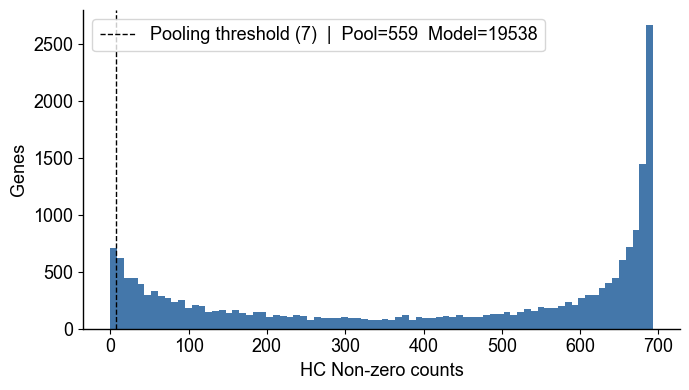

In [36]:
route = np.where(nz < MP2["nz_a_max"], "pool", "model")
gating_df = pd.DataFrame({"gene": names, "nz": nz, "route": route})
gating_df.to_csv(OUT_DIR / "gating_landscape.csv", index=False)

route_counts = gating_df["route"].value_counts()
print(route_counts)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(nz, bins=80, color="#4477aa")
ax.axvline(MP2["nz_a_max"], color="k", ls="--", lw=1,
          label=f"Pooling threshold ({MP2['nz_a_max']})  |  Pool={route_counts.get('pool',0)}  Model={route_counts.get('model',0)}")
ax.set(xlabel="HC Non-zero counts", ylabel="Genes")
ax.legend(loc="upper left")
fig.tight_layout(); fig.savefig(FIG_DIR / "gating_landscape.png", dpi=150)
plt.show()


## 2. Low-NZ model-route overdispersion

Cameron-Trivedi NB2 test justifying why low-NZ `model`-route genes (nz just above the pool gate) cannot be plain Poisson -- the premise for `nb_fixed`/`intercept` borrowing dispersion from the covariate-free trend instead of assuming Poisson. v2's demotion chain decides nbi vs nb_fixed vs intercept per-gene from actual fit outcomes rather than a second fixed NZ split, so here we test the nz band where demotion is empirically concentrated (nz<50, see Section 4/6).

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/statsmodels/genmod/families/links.py:527: RuntimeWarning: overflow encountered in exp
  return np.exp(z)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:143: RuntimeWarning: invalid value encountered in multiply
  return 1. / (self.link.deriv(mu)**2 * self.variance(mu))
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:143: RuntimeWarning: divide by zero encountered in divide
  return 1. / (self.link.deriv(mu)**2 * self.variance(mu))
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1328: RuntimeWarning: invalid value encountered in multiply
  wlsendog = (lin_pred + self.family.link.deriv(mu) * (self.endog-mu)


Low-NZ model-route genes tested (HC Non-zero counts < 50): 2272
Significantly overdispersed (Cameron-Trivedi p<0.05): 78.0%


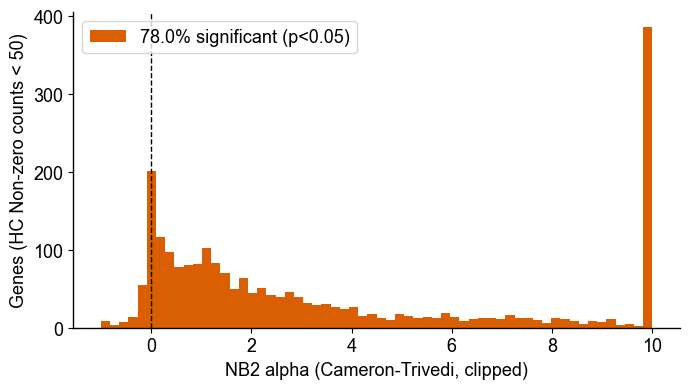

In [37]:
b_genes = gating_df.loc[(gating_df["route"] == "model") & (gating_df["nz"] < 50), "gene"].values
Xc = sm.add_constant(Xs)
rows = []
for g in b_genes:
    y = Y[:, name2idx[g]]
    try:
        res = sm.GLM(y, Xc, family=sm.families.Poisson()).fit()
    except Exception:
        continue
    mu = np.clip(res.mu, 1e-8, None)
    alpha, p = cameron_trivedi(y, mu)
    rows.append({"gene": g, "ct_alpha": alpha, "ct_p": p,
                "pearson_disp": float(res.pearson_chi2 / res.df_resid)})

overdisp_df = pd.DataFrame(rows)
overdisp_df["overdispersed"] = overdisp_df["ct_p"] < 0.05
overdisp_df.to_csv(OUT_DIR / "routeB_overdispersion.csv", index=False)

print(f"Low-NZ model-route genes tested (HC Non-zero counts < 50): {len(overdisp_df)}")
print(f"Significantly overdispersed (Cameron-Trivedi p<0.05): {overdisp_df['overdispersed'].mean():.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(overdisp_df["ct_alpha"].clip(-1, 10), bins=60, color="#d95f02",
       label=f"{overdisp_df['overdispersed'].mean():.1%} significant (p<0.05)")
ax.axvline(0, color="k", ls="--", lw=1)
ax.set(xlabel="NB2 alpha (Cameron-Trivedi, clipped)", ylabel="Genes (HC Non-zero counts < 50)")
ax.legend(loc="upper left")
fig.tight_layout(); fig.savefig(FIG_DIR / "routeB_overdispersion.png", dpi=150)
plt.show()


## 3. Dispersion trend shape: single log-log line vs lowess (used by the engine)

`build_trend`/`load_trend` here are the exact functions `model_engine_v2.py` calls. This section checks whether the engine's lowess choice is actually necessary here, or whether a single log-log line would have been adequate -- not to force a particular answer either way.

                             criterion       r2  rmse_logsigma  mae_logsigma
                   single log-log line 0.797599       0.616903      0.458036
lowess on log-log MoM (used by engine) 0.829394       0.566379      0.397009

Global fit: line R2=0.798 vs lowess R2=0.829. See 3b for whether either differs systematically by mu range.


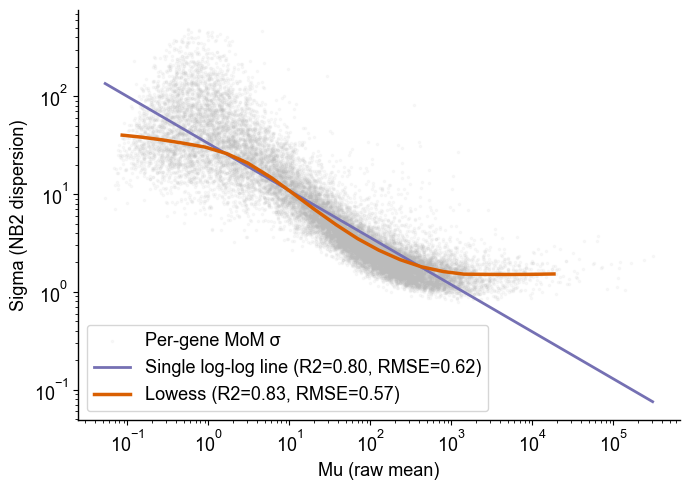

In [38]:
trend = build_trend(Y, min_nz=MP2["trend_min_nz"])  # same call the engine makes
mean_c = Y.mean(0)
var_c = Y.var(0)
with np.errstate(divide="ignore", invalid="ignore"):
    sigma_mom = np.where(mean_c > 0, (var_c - mean_c) / mean_c ** 2, np.nan)
sigma_mom = np.clip(sigma_mom, 0, None)
reliable = (nz >= MP2["trend_min_nz"]) & (mean_c > 0) & np.isfinite(sigma_mom)
mu, sig = mean_c[reliable], sigma_mom[reliable]

pos = sig > 1e-3
lx, ly = np.log(mu[pos]), np.log(sig[pos])
line = sm.OLS(ly, sm.add_constant(lx)).fit()
r2_line = float(line.rsquared)
resid_line = ly - line.predict(sm.add_constant(lx))

logmu = np.asarray(trend["lowess_logmu"])
logsig = np.asarray(trend["lowess_logsigma"])

# Same-basis comparison: interpolate the lowess curve onto the SAME lx points the
# line was fit on, then score both with the same residual-based metrics (R2, RMSE,
# MAE) instead of comparing a parametric R2 to an unscored smoother.
ly_hat_lowess = np.interp(lx, logmu, logsig, left=logsig[0], right=logsig[-1])
resid_lowess = ly - ly_hat_lowess
ss_res_lowess = float((resid_lowess ** 2).sum())
ss_tot = float(((ly - ly.mean()) ** 2).sum())
r2_lowess = 1 - ss_res_lowess / ss_tot
rmse_line = float(np.sqrt((resid_line ** 2).mean()))
rmse_lowess = float(np.sqrt((resid_lowess ** 2).mean()))
mae_line = float(np.abs(resid_line).mean())
mae_lowess = float(np.abs(resid_lowess).mean())

trend_comparison = pd.DataFrame({
    "criterion": ["single log-log line", "lowess on log-log MoM (used by engine)"],
    "r2": [r2_line, r2_lowess],
    "rmse_logsigma": [rmse_line, rmse_lowess],
    "mae_logsigma": [mae_line, mae_lowess],
})
trend_comparison.to_csv(OUT_DIR / "dispersion_trend_fit_comparison.csv", index=False)
print(trend_comparison.to_string(index=False))
print(f"\nGlobal fit: line R2={r2_line:.3f} vs lowess R2={r2_lowess:.3f}. "
     "See 3b for whether either differs systematically by mu range.")

grid = np.geomspace(mu.min(), mu.max(), 200)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(mu, sig, s=3, alpha=0.08, color="#bbbbbb", label="Per-gene MoM σ")
ax.plot(grid, np.exp(line.params[0] + line.params[1] * np.log(grid)), color="#7570b3",
       lw=2, label=f"Single log-log line (R2={r2_line:.2f}, RMSE={rmse_line:.2f})")
ax.plot(np.exp(logmu), np.exp(logsig), color="#d95f02", lw=2.5,
       label=f"Lowess (R2={r2_lowess:.2f}, RMSE={rmse_lowess:.2f})")
ax.set(xscale="log", yscale="log", xlabel="Mu (raw mean)", ylabel="Sigma (NB2 dispersion)")
ax.legend(loc="lower left"); fig.tight_layout()
fig.savefig(FIG_DIR / "dispersion_trend_fit_comparison.png", dpi=150)
plt.show()


### 3b. Is the line actually worse, or does the global R2/RMSE just hide it?

Global R2/RMSE average over all points, so a line that is biased at the low-mu and high-mu ends but fine in the middle can still score similarly to lowess overall (the middle dominates the point count). Bin by mu quintile and look at **signed** mean residual (bias) and RMSE per bin -- this is the only way to tell whether the line's plateau-mismatch actually matters, or whether a single line is in fact adequate here.

          mu_range    n  bias_line  bias_lowess  rmse_line  rmse_lowess
     [0.053, 0.83] 2263     -0.103        0.338      0.898        0.885
       [0.83, 3.4] 2264      0.389        0.399      0.887        0.896
         [3.4, 15] 2265      0.172        0.149      0.571        0.559
          [15, 40] 2263     -0.107        0.011      0.419        0.402
          [40, 85] 2265     -0.270       -0.084      0.433        0.348
     [85, 1.8e+02] 2264     -0.257       -0.082      0.435        0.361
[1.8e+02, 4.2e+02] 2264     -0.157       -0.078      0.401        0.374
  [4.2e+02, 3e+05] 2265      0.332       -0.040      0.642        0.341


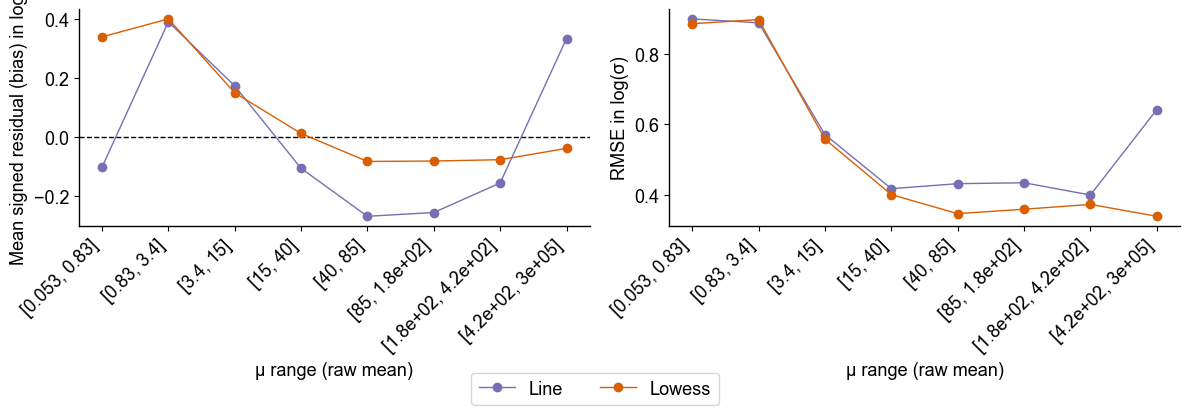

In [46]:
n_q = 8
q_edges = np.quantile(lx, np.linspace(0, 1, n_q + 1))
q_edges[0] -= 1e-6
qbin = np.clip(np.digitize(lx, q_edges) - 1, 0, n_q - 1)

rows = []
for b in range(n_q):
    m = qbin == b
    if m.sum() < 5:
        continue
    rows.append({
        "mu_range": f"[{np.exp(lx[m].min()):.2g}, {np.exp(lx[m].max()):.2g}]",
        "n": int(m.sum()),
        "bias_line": float(resid_line[m].mean()),
        "bias_lowess": float(resid_lowess[m].mean()),
        "rmse_line": float(np.sqrt((resid_line[m] ** 2).mean())),
        "rmse_lowess": float(np.sqrt((resid_lowess[m] ** 2).mean())),
    })
bin_df = pd.DataFrame(rows)
bin_df.to_csv(OUT_DIR / "dispersion_trend_fit_by_mu_bin.csv", index=False)
print(bin_df.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = range(len(bin_df))
axes[0].axhline(0, color="k", ls="--", lw=1)
axes[0].plot(x, bin_df["bias_line"], "-o", color="#7570b3", label="Line")
axes[0].plot(x, bin_df["bias_lowess"], "-o", color="#d95f02", label="Lowess")
axes[0].set(ylabel="Mean signed residual (bias) in log(σ)")
axes[1].plot(x, bin_df["rmse_line"], "-o", color="#7570b3", label="Line")
axes[1].plot(x, bin_df["rmse_lowess"], "-o", color="#d95f02", label="Lowess")
axes[1].set(ylabel="RMSE in log(σ)")
for ax in axes:
    ax.set_xlabel("μ range (raw mean)")
    ax.set_xticks(list(x)); ax.set_xticklabels(bin_df["mu_range"], rotation=45, ha="right")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))
fig.tight_layout(); fig.savefig(FIG_DIR / "dispersion_trend_fit_by_mu_bin.png", dpi=150)
plt.show()


## 4. Fit-stage viability vs observation count (NZ)

Empirically derive the NZ floor that justifies the pooling gate. For every gene, apply the engine's three model stages **standalone** with identical logic and thresholds (`config.MODELING_PARAMS_V2`), then bin by NZ in steps of 10:

- **stage nbi** - full NBI GAMLSS (mu AND sigma regressed on covariates), R `gamlss`, same beta-explode guard (`beta_explode_thr`) as `model_engine_v2._fit_nbi`.
- **stage nb_fixed** - mean-only NB, dispersion FIXED from the covariate-free trend, GAIC full-vs-intercept (`fit_route_b_gene`, exact engine call).
- **stage intercept** - closed-form intercept-only NB (`fit_intercept_only_gene`).

Per NZ bin we report (a) fit success rate of each stage, and (b) in-sample RQR degeneracy `std(z)` and normality `W1` as a fit-quality proxy. In-sample RQR overstates calibration, so it is a **necessary-not-sufficient** viability check: a stage whose in-sample z already collapses cannot possibly be trusted out-of-sample. Finally we run the actual demotion chain (nbi -> nb_fixed -> intercept -> excluded) to show the NZ level below which every regression stage collapses and **pooling is the only remaining route**. Vertical marker at `nz_a_max`.

In [47]:
import os
import rpy2.robjects as ro
from model_engine_v2 import (_nbi_rqr_from_coeffs, _to_r_matrix, _to_r_vec,
                             fit_intercept_only_gene, fit_route_b_gene)

PER_BIN = 40          # genes sampled per NZ bin (lower for a quick pass)
BIN_W = 10
NZ_MAX = 160          # sweep NZ in [0, NZ_MAX); one extra high-NZ reference bin added
SAMPLE_SEED = 0

if os.path.isfile(OUT_DIR / "stage_viability_vs_nz.csv") : 
    stage_df = pd.read_csv(OUT_DIR / "stage_viability_vs_nz.csv")
else:
    
    # Self-contained: recompute NZ locally so this block runs independently of the
    # gating cells above.
    nz = (Y > 0).sum(0).astype(int)
    name2idx = {g: i for i, g in enumerate(names)}


    build_trend(Y, min_nz=MP2["trend_min_nz"])   # same trend the engine fixes dispersion to
    alpha_fn = load_trend()
    Xc = sm.add_constant(Xs)
    BET = MP2["beta_explode_thr"]

    ro.r(f'source("{config.R_HELPER}")')
    _r_nbi = ro.globalenv["train_nbi_coeffs"]
    
    def try_nbi(y):
        # Mirrors model_engine_v2._fit_nbi exactly: R gamlss NBI, then beta-explode guard.
        try:
            r = _r_nbi(_to_r_vec(y), _to_r_matrix(Xs, config.BIAS_COLUMNS),
                    ro.IntVector([50]), ro.FloatVector([MP2["outlier_z"]]),
                    ro.IntVector([MP2["max_outlier_iter"]]), ro.FloatVector([MP2["max_remove_frac"]]),
                    ro.FloatVector([MP2["ridge_lambda_sigma"]]))
        except Exception as e:
            return dict(ok=False, reason=f"nbi_err:{str(e)[:24]}")
        if not bool(r.rx2("success")[0]):
            return dict(ok=False, reason=str(r.rx2("msg")[0])[:24] or "not_converged")
        mu_c, sg_c = np.array(r.rx2("mu_coef")), np.array(r.rx2("sigma_coef"))
        if float(np.abs(mu_c[1:]).max()) > BET or float(np.abs(sg_c[1:]).max()) > BET:
            return dict(ok=False, reason="beta_explode")
        return dict(ok=True, reason="", mu_coef=mu_c, sigma_coef=sg_c)


    def _stdw1(z):
        v = z[np.isfinite(z)]
        if len(v) < 8:
            return np.nan, np.nan
        return float(v.std()), w1_normal(v)


    def eval_stages(j):
        y = Y[:, j]
        out = {"gene": names[j], "nz": int(nz[j])}

        r = try_nbi(y)
        out["nbi_ok"], out["nbi_reason"] = r["ok"], r["reason"]
        if r["ok"]:
            z = _nbi_rqr_from_coeffs(r["mu_coef"], r["sigma_coef"], Xs, y, 0)
            out["nbi_std"], out["nbi_w1"] = _stdw1(z)

        try:
            rb = fit_route_b_gene(y, Xs, alpha_fn, MP2["outlier_z"], MP2["max_outlier_iter"],
                                MP2["max_remove_frac"], beta_explode_thr=BET, gaic_k=MP2["gaic_k"])
            out["nbf_ok"], out["nbf_reason"] = rb["success"], rb.get("fail_reason", "")
            if rb["success"]:
                beta = rb["beta"] if rb["chosen"] == "full" else rb["beta_null"]
                mu = (np.exp(Xc @ beta).clip(1e-6, 1e8) if rb["chosen"] == "full"
                    else np.full(len(y), np.exp(beta[0])))
                out["nbf_chosen"] = rb["chosen"]
                out["nbf_std"], out["nbf_w1"] = _stdw1(_nb_rqr(y, mu, rb["alpha"], 0))
        except Exception as e:
            out["nbf_ok"], out["nbf_reason"] = False, str(e)[:24]

        ri = fit_intercept_only_gene(y, alpha_fn)
        out["int_ok"], out["int_reason"] = ri["success"], ri.get("fail_reason", "")
        if ri["success"]:
            mu = np.full(len(y), np.exp(ri["beta"][0]))
            out["int_std"], out["int_w1"] = _stdw1(_nb_rqr(y, mu, ri["alpha"], 0))
        return out


    rng = np.random.default_rng(SAMPLE_SEED)
    bin_los = list(range(0, NZ_MAX, BIN_W))
    sample_idx = []
    for lo in bin_los:
        idx = np.where((nz >= lo) & (nz < lo + BIN_W))[0]
        if len(idx):
            sample_idx += list(rng.choice(idx, size=min(PER_BIN, len(idx)), replace=False))
    hi = np.where(nz >= NZ_MAX)[0]                    # high-NZ reference bin
    if len(hi):
        sample_idx += list(rng.choice(hi, size=min(PER_BIN, len(hi)), replace=False))

    print(f"Sampling {len(sample_idx)} genes across NZ bins (PER_BIN={PER_BIN})...")
    stage_rows = [eval_stages(int(j)) for j in sample_idx]
    stage_df = pd.DataFrame(stage_rows)
    stage_df.to_csv(OUT_DIR / "stage_viability_vs_nz.csv", index=False)
    print(f"done. columns: {list(stage_df.columns)}")

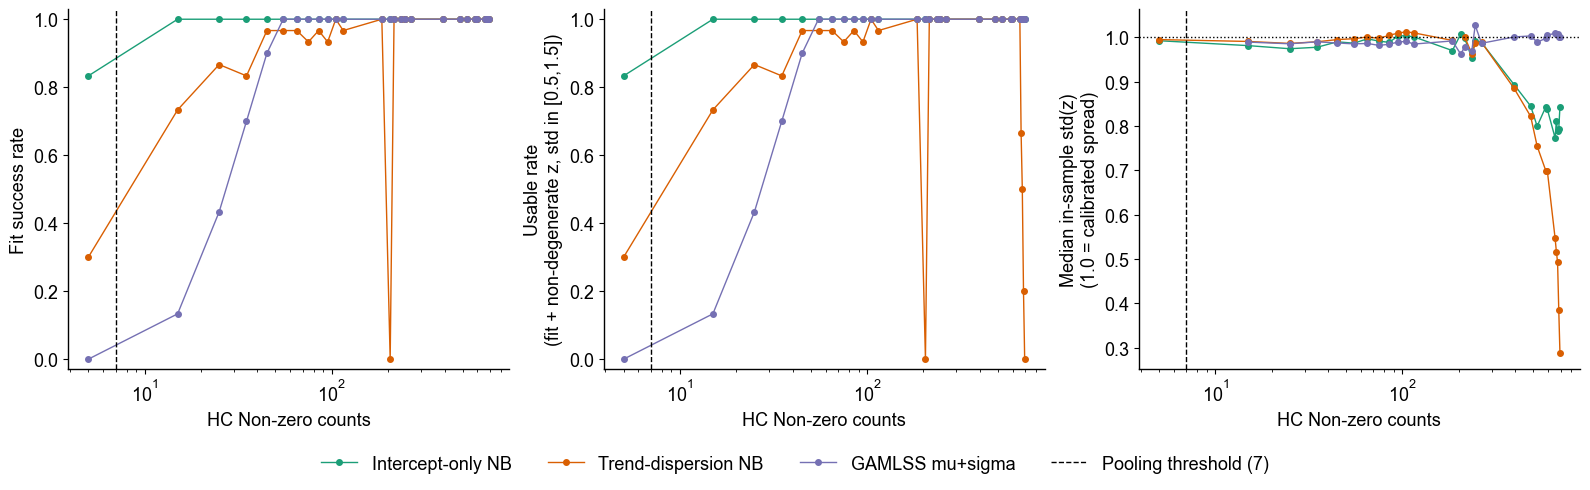

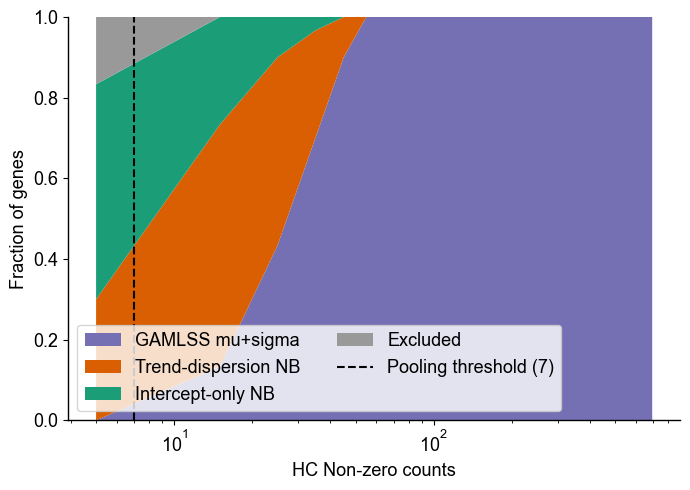

 nz_bin  n_genes  int_fit_rate  int_usable_rate  int_std_med  int_w1_med  nbf_fit_rate  nbf_usable_rate  nbf_std_med  nbf_w1_med  nbi_fit_rate  nbi_usable_rate  nbi_std_med  nbi_w1_med
      0       30         0.833            0.833        0.992       0.053         0.300            0.300        0.995       0.053         0.000            0.000          NaN         NaN
     10       30         1.000            1.000        0.981       0.051         0.733            0.733        0.990       0.054         0.133            0.133        0.989       0.053
     20       30         1.000            1.000        0.974       0.048         0.867            0.867        0.986       0.056         0.433            0.433        0.985       0.050
     30       30         1.000            1.000        0.977       0.053         0.833            0.833        0.990       0.059         0.700            0.700        0.990       0.048
     40       30         1.000            1.000        0.990       0.054   

In [62]:
# Bin by NZ (width 10) and summarize each stage. "Usable" = fit succeeded AND the
# in-sample RQR is not degenerate (std within [STD_LO, STD_HI]); a fit whose z has
# already collapsed in-sample cannot be trusted, so it does not count as viable.
STD_LO, STD_HI = 0.5, 1.5
STAGES = [("int", "#1b9e77"),("nbf", "#d95f02"),("nbi", "#7570b3")]
LBL = {"nbi": "GAMLSS mu+sigma", "nbf": "Trend-dispersion NB", "int": "Intercept-only NB"}

d = stage_df.copy()
d["nz_bin"] = (d["nz"] // BIN_W) * BIN_W
for s, _ in STAGES:
    ok = d[f"{s}_ok"].fillna(False).astype(bool)
    usable = ok & d[f"{s}_std"].between(STD_LO, STD_HI)
    d[f"{s}_usable"] = usable

grp = d.groupby("nz_bin")
summary = pd.DataFrame({"n_genes": grp.size()})
for s, _ in STAGES:
    summary[f"{s}_fit_rate"] = grp[f"{s}_ok"].mean()
    summary[f"{s}_usable_rate"] = grp[f"{s}_usable"].mean()
    summary[f"{s}_std_med"] = grp[f"{s}_std"].median()
    summary[f"{s}_w1_med"] = grp[f"{s}_w1"].median()
summary = summary.reset_index()
summary.to_csv(OUT_DIR / "stage_viability_by_nz_bin.csv", index=False)

# Actual demotion chain outcome per gene: first stage that is USABLE, else excluded.
def chain_outcome(r):
    for s in ["nbi", "nbf", "int"]:
        if r[f"{s}_usable"]:
            return s
    return "excluded"
d["final_stage"] = d.apply(chain_outcome, axis=1)
comp = (d.groupby(["nz_bin", "final_stage"]).size().unstack(fill_value=0))
comp = comp.div(comp.sum(1), axis=0)
for col in ["nbi", "nbf", "int", "excluded"]:
    if col not in comp:
        comp[col] = 0.0
comp = comp[["nbi", "nbf", "int", "excluded"]]
comp.to_csv(OUT_DIR / "demotion_chain_composition_by_nz.csv")

x = summary["nz_bin"] + BIN_W / 2
nz_a = MP2["nz_a_max"]
NZ_LABEL = "HC Non-zero counts"

# 3 line plots share one legend (same 3 series everywhere) instead of repeating
# it in each panel.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
for s, c in STAGES:
    ax.plot(x, summary[f"{s}_fit_rate"], "-o", ms=4, color=c, label=LBL[s])
ax.axvline(nz_a, color="k", ls="--", lw=1, label=f"Pooling threshold ({nz_a})")
ax.set_xscale("log")
ax.set(xlabel=NZ_LABEL, ylabel="Fit success rate", ylim=(-0.03, 1.03))

ax = axes[1]
for s, c in STAGES:
    ax.plot(x, summary[f"{s}_usable_rate"], "-o", ms=4, color=c, label=LBL[s])
ax.axvline(nz_a, color="k", ls="--", lw=1)
ax.set_xscale("log")
ax.set(xlabel=NZ_LABEL, ylabel=f"Usable rate\n(fit + non-degenerate z, std in [{STD_LO},{STD_HI}])",
      ylim=(-0.03, 1.03))

ax = axes[2]
for s, c in STAGES:
    ax.plot(x, summary[f"{s}_std_med"], "-o", ms=4, color=c, label=LBL[s])
ax.axhline(1.0, color="k", ls=":", lw=1)
ax.axvline(nz_a, color="k", ls="--", lw=1)
ax.set_xscale("log")
ax.set(xlabel=NZ_LABEL, ylabel="Median in-sample std(z)\n(1.0 = calibrated spread)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "stage_viability_vs_nz.png", dpi=300, bbox_inches="tight")
plt.show()

# Stacked-area instead of bar: bar-per-bin left wide visual gaps wherever a bin's
# genes were 0 (nothing to stack), especially in the sparse high-NZ tail (n=1-5).
# stackplot draws a continuous band between the actual sampled x points instead,
# so sparse bins no longer read as "missing data". Kept as its own figure since it
# is a different metric (route composition) from the 3 calibration line plots above.
fig2, ax = plt.subplots(figsize=(7, 5))
cols = {"nbi": "#7570b3", "nbf": "#d95f02", "int": "#1b9e77", "excluded": "#999999"}
order = ["nbi", "nbf", "int", "excluded"]
order_labels = [LBL["nbi"], LBL["nbf"], LBL["int"], "Excluded"]
comp_x = comp.index.values + BIN_W / 2
ax.stackplot(comp_x, [comp[col].values for col in order],
            labels=order_labels, colors=[cols[c] for c in order])
ax.axvline(nz_a, color="k", ls="--", lw=1.5, label=f"Pooling threshold ({nz_a})")
ax.set_xscale("log")
ax.set(xlabel=NZ_LABEL, ylabel="Fraction of genes", ylim=(0, 1))
ax.legend(ncol=2, loc="lower left")
fig2.tight_layout()
fig2.savefig(FIG_DIR / "demotion_chain_composition_vs_nz.png", dpi=300, bbox_inches="tight")
plt.show()

print(summary.round(3).to_string(index=False))

## 5. Held-out (CV) re-check of the same NZ sweep

Section 4 above is in-sample: for very sparse genes (mostly y=0), F(0)≈1
regardless of model quality, so RQR z looks close to N(0,1) even when the
covariate structure is wrong (the same optimism bias already documented for
Route A). This section re-evaluates the exact same sampled gene set with real
5-fold held-out CV (`cv_model_engine_v2.cv_nbi/cv_nb_fixed/cv_intercept`,
same functions the production CV script uses) to see whether the good
in-sample numbers at low NZ survive.

In [51]:
import time

from sklearn.model_selection import StratifiedKFold

from cv_model_engine_v2 import cv_intercept, cv_nb_fixed, cv_nbi
from model_engine_v2 import _w1_normal

cv_genes = stage_df["gene"].tolist()
heldout_cache = OUT_DIR / "stage_viability_vs_nz_heldout.csv"
if os.path.isfile(heldout_cache):
    cv_df = pd.read_csv(heldout_cache)
    print(f"Loaded cached held-out CV result -> {heldout_cache}  ({len(cv_df)} genes)")
else:
    build_trend(Y, min_nz=MP2["trend_min_nz"])
    alpha_fn = load_trend()

    ro.r(f'source("{config.R_HELPER}")')
    r_fit_gene = ro.globalenv["fit_gamlss_gene"]

    folds = list(StratifiedKFold(MP2["n_splits"], shuffle=True, random_state=42)
                .split(np.zeros(len(strata)), strata))

    def _stdw1_cv(z):
        v = z[np.isfinite(z)]
        if len(v) < 8:
            return np.nan, np.nan, len(v)
        return float(v.std()), _w1_normal(v), len(v)

    t0 = time.perf_counter()
    cv_rows = []
    for k, g in enumerate(cv_genes):
        j = name2idx[g]
        y = Y[:, j]
        row = {"gene": g, "nz": int(nz[j])}

        # cv_nbi/cv_nb_fixed/cv_intercept return (z, fold_info, mu, sigma) since
        # cv_model_engine_v2.py started tracking per-fold posterior-predictive-check
        # data -- only z is needed here, the rest is discarded.
        z_nbi, _, _, _ = cv_nbi(y, Xs, folds, r_fit_gene, config.BIAS_COLUMNS,
                                MP2["outlier_z"], MP2["max_outlier_iter"], MP2["max_remove_frac"],
                                MP2["ridge_lambda_sigma"], seed=42)
        row["nbi_std"], row["nbi_w1"], row["nbi_nvalid"] = _stdw1_cv(z_nbi)

        z_nbf, _, _, _ = cv_nb_fixed(y, Xs, folds, alpha_fn, MP2["outlier_z"], MP2["max_outlier_iter"],
                                     MP2["max_remove_frac"], seed=42,
                                     beta_explode_thr=MP2["beta_explode_thr"], gaic_k=MP2["gaic_k"])
        row["nbf_std"], row["nbf_w1"], row["nbf_nvalid"] = _stdw1_cv(z_nbf)

        z_int, _, _, _ = cv_intercept(y, alpha_fn, folds, seed=42)
        row["int_std"], row["int_w1"], row["int_nvalid"] = _stdw1_cv(z_int)

        cv_rows.append(row)
        if (k + 1) % 50 == 0:
            print(f"  [{k+1}/{len(cv_genes)}]  elapsed={time.perf_counter()-t0:.0f}s")

    cv_df = pd.DataFrame(cv_rows)
    cv_df.to_csv(heldout_cache, index=False)
    print(f"done in {time.perf_counter()-t0:.0f}s -- {len(cv_genes)} genes x 5 folds")

Loaded cached held-out CV result -> /project/cfRNA_NormativeModeling/EDA_Modeling/Analysis_Results/stage_viability_vs_nz_heldout.csv  (390 genes)


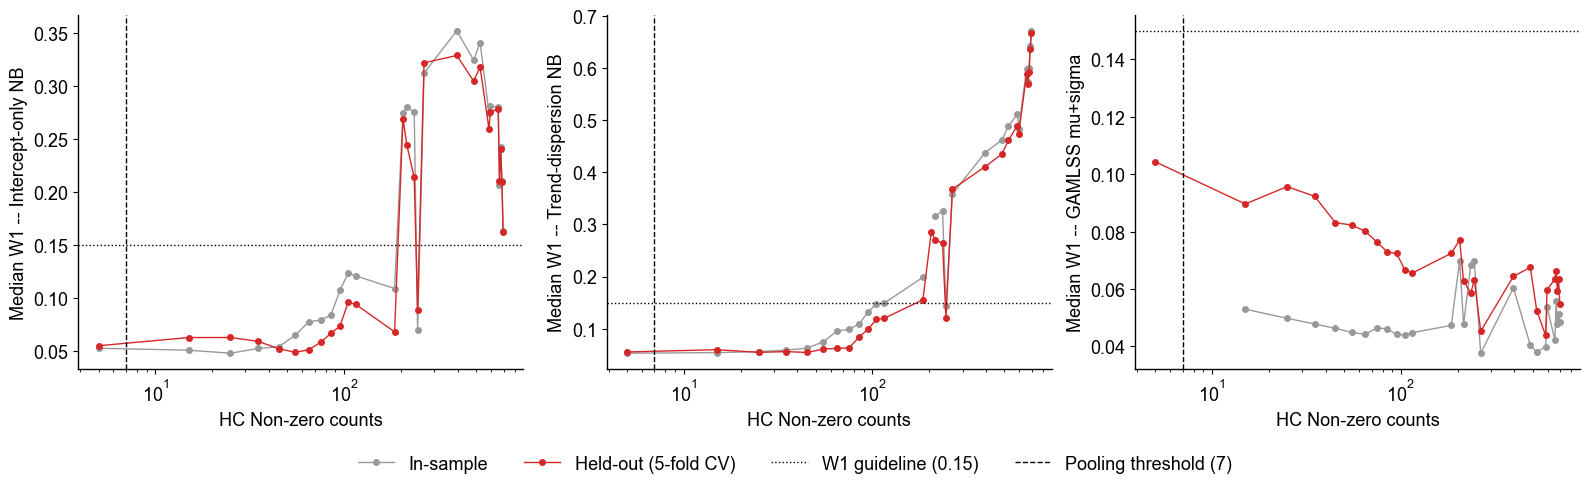

 nz_bin  n_genes  int_w1_med  int_std_med  int_nvalid_med  nbf_w1_med  nbf_std_med  nbf_nvalid_med  nbi_w1_med  nbi_std_med  nbi_nvalid_med
      0       30       0.055        0.945           693.0       0.055        0.945           693.0       0.104        1.098           346.0
     10       30       0.063        0.949           693.0       0.060        0.957           693.0       0.090        1.149           693.0
     20       30       0.063        0.952           693.0       0.054        0.964           693.0       0.096        1.141           693.0
     30       30       0.059        0.953           693.0       0.056        0.996           693.0       0.092        1.137           693.0
     40       30       0.052        0.962           693.0       0.054        0.998           693.0       0.083        1.119           693.0
     50       30       0.049        0.968           693.0       0.061        1.012           693.0       0.082        1.112           693.0
     60       30    

In [55]:
cv_d = cv_df.copy()
cv_d["nz_bin"] = (cv_d["nz"] // BIN_W) * BIN_W
grp_cv = cv_d.groupby("nz_bin")
summary_cv = pd.DataFrame({"n_genes": grp_cv.size()})
for s, _ in STAGES:
    summary_cv[f"{s}_w1_med"] = grp_cv[f"{s}_w1"].median()
    summary_cv[f"{s}_std_med"] = grp_cv[f"{s}_std"].median()
    summary_cv[f"{s}_nvalid_med"] = grp_cv[f"{s}_nvalid"].median()
summary_cv = summary_cv.reset_index()
summary_cv.to_csv(OUT_DIR / "stage_viability_by_nz_bin_heldout.csv", index=False)

x_cv = summary_cv["nz_bin"] + BIN_W / 2
W1_GUIDE = 0.15

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, s_show in zip(axes, ["int", "nbf", "nbi"]):
    ax.plot(x, summary[f"{s_show}_w1_med"], "-o", ms=4, color="#999999", label="In-sample")
    ax.plot(x_cv, summary_cv[f"{s_show}_w1_med"], "-o", ms=4, color="#d62728", label="Held-out (5-fold CV)")
    ax.axhline(W1_GUIDE, color="k", ls=":", lw=1, label=f"W1 guideline ({W1_GUIDE})")
    ax.axvline(nz_a, color="k", ls="--", lw=1, label=f"Pooling threshold ({nz_a})")
    ax.set_xscale("log")
    ax.set(xlabel=NZ_LABEL, ylabel=f"Median W1 -- {LBL[s_show]}")
handle, labels = axes[0].get_legend_handles_labels()
fig.legend(handle, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "stage_viability_insample_vs_heldout.png", dpi=300, bbox_inches="tight")
plt.show()

print(summary_cv.round(3).to_string(index=False))

## 6. Full-engine stage composition vs NZ (all 19538 `model`-route genes, actual trained engine)

Sections 4-5 fit fresh, standalone stages on a per-NZ-bin *sample* of genes, because fitting all three stages for every gene would take as long as training the whole engine again. This section instead reads `engine_state_v2/training_summary.csv` -- the actual production engine's final route/stage per gene, already trained on the full HC set -- so it costs nothing to cover every `model`-route gene exhaustively. It answers a narrower question than Section 4 (only the *chosen* stage per gene, not the viability of all three), but with no sampling: is there any high-NZ tail where demotion (nbi -> nb_fixed/intercept) still happens?

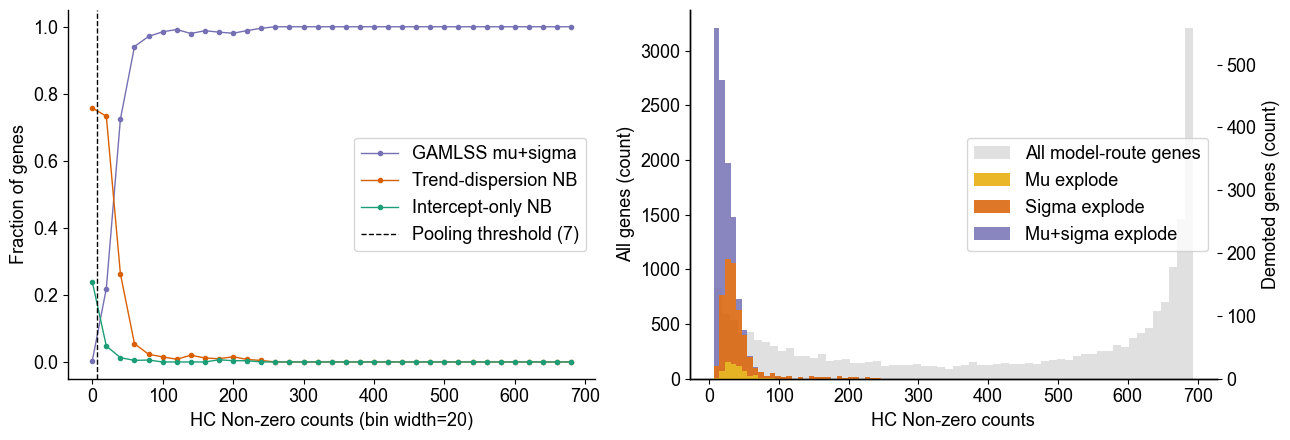

HC Non-zero counts>200 sigma-explode demotions: 8 / 19538 model-route genes


In [61]:
summary_v2 = pd.read_csv(config.ENGINE_DIR_V2 / "training_summary.csv")
model_v2 = summary_v2[summary_v2["route"] == "model"].copy()

BIN_W2 = 20
NZ_MAX2 = 700
model_v2["nz_bin"] = (model_v2["nz"] // BIN_W2) * BIN_W2
model_v2.loc[model_v2["nz_bin"] > NZ_MAX2, "nz_bin"] = NZ_MAX2

STAGES2 = ["nbi", "nb_fixed", "intercept"]
COLORS2 = {"nbi": "#7570b3", "nb_fixed": "#d95f02", "intercept": "#1b9e77"}
LBL2 = {"nbi": "GAMLSS mu+sigma", "nb_fixed": "Trend-dispersion NB", "intercept": "Intercept-only NB"}
NZ_LABEL2 = "HC Non-zero counts"

grp2 = model_v2.groupby("nz_bin")
frac2 = grp2["stage"].value_counts(normalize=True).unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
x2 = frac2.index.values
for s in STAGES2:
    if s in frac2.columns:
        ax.plot(x2, frac2[s], color=COLORS2[s], marker="o", ms=3, label=LBL2[s])
ax.axvline(MP2["nz_a_max"], color="k", ls="--", lw=1, label=f"Pooling threshold ({MP2['nz_a_max']})")
ax.set(xlabel=f"{NZ_LABEL2} (bin width=20)", ylabel="Fraction of genes")
ax.legend(loc="right")

ax2 = axes[1]
sigma_explode = model_v2[model_v2["nbi_explode"] == "sigma"]
mu_explode = model_v2[model_v2["nbi_explode"] == "mu"]
mixed_explode = model_v2[model_v2["nbi_explode"] == "mu+sigma"]
ax2.hist(model_v2["nz"], bins=60, color="#cccccc", alpha=0.6, label="All model-route genes")
ax2b = ax2.twinx()
ax2b.hist([mu_explode["nz"], sigma_explode["nz"], mixed_explode["nz"]], bins=30,
          stacked=True, color=["#e6ab02", "#d95f02", "#7570b3"],
          label=["Mu explode", "Sigma explode", "Mu+sigma explode"], alpha=0.85)
ax2.set(xlabel=NZ_LABEL2, ylabel="All genes (count)")
ax2b.set_ylabel("Demoted genes (count)")
h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc="right")

fig.tight_layout()
fig.savefig(FIG_DIR / "stage_composition_vs_nz_fullengine.png", dpi=150)
plt.show()

n_high_sigma = int((model_v2.loc[model_v2["nz"] > 200, "nbi_explode"] == "sigma").sum())
print(f"HC Non-zero counts>200 sigma-explode demotions: {n_high_sigma} / {len(model_v2)} model-route genes")
